# VAR Multivariate Time Series Analysis
## Air Quality, Electricity & Industrial Production (Malaysia 2018–2022)

**Models:**
1. VAR 1 — Car Registrations + Electricity Local → NO₂
2. VAR 2 — IPI Index + Electricity Local → SO₂
3. VAR 3 (Optional) — NO₂ → PM2.5

**Outputs:** IRF, FEVD, Granger Causality, Durbin-Watson diagnostics

## 1. Imports & Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')

from statsmodels.tsa.api import VAR
from statsmodels.tsa.stattools import adfuller, grangercausalitytests
from statsmodels.stats.stattools import durbin_watson

print("All libraries imported successfully.")


All libraries imported successfully.


## 2. Load & Inspect Data

In [3]:
# Load the cleaned combined dataset
df = pd.read_csv('../COS40007DataCleaning/combined_air_electricity_ipi_cleaned.csv', parse_dates=['date'])
df = df.set_index('date').sort_index()
df.index.freq = 'MS'  # Monthly Start frequency

print("Dataset shape:", df.shape)
print("Date range:", df.index.min(), "to", df.index.max())
print()
print("Columns:")
for c in df.columns:
    print(f"  {c:40s} nulls: {df[c].isnull().sum()}")

df.head()


Dataset shape: (60, 19)
Date range: 2018-01-01 00:00:00 to 2022-12-01 00:00:00

Columns:
  air_co                                   nulls: 0
  air_no2                                  nulls: 0
  air_o3                                   nulls: 0
  air_pm_10                                nulls: 0
  air_pm_25                                nulls: 0
  air_so2                                  nulls: 0
  electricity_exports                      nulls: 0
  electricity_local                        nulls: 0
  electricity_local_commercial             nulls: 0
  electricity_local_domestic               nulls: 0
  electricity_losses                       nulls: 0
  electricity_total                        nulls: 0
  ipi_abs_index                            nulls: 0
  ipi_growth_mom_index                     nulls: 0
  ipi_growth_yoy_index                     nulls: 0
  ipi_abs_index_sa                         nulls: 0
  ipi_growth_mom_index_sa                  nulls: 0
  ipi_growth_yoy_index_sa  

,air_co,air_no2,air_o3,air_pm_10,air_pm_25,air_so2,electricity_exports,electricity_local,electricity_local_commercial,electricity_local_domestic,electricity_losses,electricity_total,ipi_abs_index,ipi_growth_mom_index,ipi_growth_yoy_index,ipi_abs_index_sa,ipi_growth_mom_index_sa,ipi_growth_yoy_index_sa,car_registration
date,,,,,,,,,,,,,,,,,,,
2018-01-01,0.671,0.0078,0.015,19.14,11.43,0.0010,109.820,11845.900250,9390.080801,2455.819450,1200.383806,13156.104056,113.447,1.264,4.838,109.866,0.013,3.963,47162
2018-02-01,0.677,0.0069,0.024,26.06,16.75,0.0011,101.500,11091.957006,8561.415143,2530.541863,903.839625,12097.296631,101.820,-10.249,2.344,110.830,0.877,2.625,41705
2018-03-01,0.654,0.0074,0.019,24.84,15.61,0.0010,103.785,12244.089947,9659.320215,2584.769732,1681.104546,14028.979493,112.270,10.264,2.921,111.090,0.235,3.328,49810
2018-04-01,0.682,0.0075,0.019,25.64,16.34,0.0010,102.002,12018.584577,9340.784017,2677.800560,1484.235112,13604.821689,108.986,-2.925,4.977,113.036,1.752,5.918,47834
2018-05-01,0.671,0.0076,0.017,22.60,14.54,0.0010,142.261,12267.998390,9525.937602,2742.060788,1524.423335,13934.682725,111.631,2.426,3.502,112.183,-0.755,4.320,44598


## 3. Stationarity Testing — Augmented Dickey-Fuller

Before fitting a VAR model, all series must be stationary (constant mean and variance over time).
- **H₀:** Series has a unit root (non-stationary)
- **Reject H₀ if p < 0.05** → series is stationary
- Non-stationary series are first-differenced and re-tested


In [4]:
def adf_summary(series, name):
    """Run ADF test and return result as a dict."""
    result = adfuller(series.dropna(), autolag='AIC')
    return {
        'Variable'  : name,
        'ADF Stat'  : round(result[0], 4),
        'p-value'   : round(result[1], 4),
        'Stationary': 'Yes' if result[1] < 0.05 else 'No'
    }

# Test all VAR variables
target_vars = ['car_registration', 'electricity_local', 'air_no2',
               'ipi_abs_index', 'air_so2', 'air_pm_25']

adf_rows = [adf_summary(df[c], c) for c in target_vars]
adf_df   = pd.DataFrame(adf_rows)

print("=== Augmented Dickey-Fuller Test Results ===")
print(adf_df.to_string(index=False))
print()
print("Non-stationary series (p >= 0.05):")
non_stat = adf_df[adf_df['Stationary'] == 'No']['Variable'].tolist()
print(" ", non_stat, "→ will be first-differenced")


=== Augmented Dickey-Fuller Test Results ===
         Variable  ADF Stat  p-value Stationary
 car_registration   -3.8356   0.0026        Yes
electricity_local   -4.2485   0.0005        Yes
          air_no2   -2.6891   0.0759         No
    ipi_abs_index   -3.3946   0.0111        Yes
          air_so2    0.5233   0.9856         No
        air_pm_25   -4.4320   0.0003        Yes

Non-stationary series (p >= 0.05):
  ['air_no2', 'air_so2'] → will be first-differenced


## 4. Make Series Stationary

Series that fail the ADF test are differenced once (Δ) and re-tested.
If still non-stationary, differenced a second time (Δ²).


In [5]:
def make_stationary(df_in):
    """
    For each column in df_in:
      - If already stationary (ADF p < 0.05): keep as-is
      - Else: first-difference; if still non-stationary, second-difference
    Returns a new DataFrame with all stationary series (columns prefixed d_ or d2_ if differenced).
    """
    out = {}
    for col in df_in.columns:
        s = df_in[col].dropna()
        r = adfuller(s, autolag='AIC')
        if r[1] < 0.05:
            out[col] = s
            print(f"  {col:<35} → STATIONARY   (p={r[1]:.4f}) — kept as-is")
        else:
            d = s.diff().dropna()
            r2 = adfuller(d, autolag='AIC')
            if r2[1] < 0.05:
                out[f'd_{col}'] = d
                print(f"  {col:<35} → DIFFERENCED  (p={r2[1]:.4f}) — using Δ{col}")
            else:
                d2 = d.diff().dropna()
                out[f'd2_{col}'] = d2
                print(f"  {col:<35} → 2nd DIFF     (p={adfuller(d2,autolag='AIC')[1]:.4f}) — using Δ²{col}")
    return pd.DataFrame(out).dropna()


print("VAR1 — Car Reg + Electricity Local + NO₂:")
v1_raw = df[['car_registration', 'electricity_local', 'air_no2']].copy()
v1 = make_stationary(v1_raw)
print(f"  Final columns: {v1.columns.tolist()}  |  Shape: {v1.shape}\n")

print("VAR2 — IPI + Electricity Local + SO₂:")
v2_raw = df[['ipi_abs_index', 'electricity_local', 'air_so2']].copy()
v2 = make_stationary(v2_raw)
print(f"  Final columns: {v2.columns.tolist()}  |  Shape: {v2.shape}\n")

print("VAR3 — NO₂ + PM2.5:")
v3_raw = df[['air_no2', 'air_pm_25']].copy()
v3 = make_stationary(v3_raw)
print(f"  Final columns: {v3.columns.tolist()}  |  Shape: {v3.shape}")


VAR1 — Car Reg + Electricity Local + NO₂:
  car_registration                    → STATIONARY   (p=0.0026) — kept as-is
  electricity_local                   → STATIONARY   (p=0.0005) — kept as-is
  air_no2                             → DIFFERENCED  (p=0.0000) — using Δair_no2
  Final columns: ['car_registration', 'electricity_local', 'd_air_no2']  |  Shape: (59, 3)

VAR2 — IPI + Electricity Local + SO₂:
  ipi_abs_index                       → STATIONARY   (p=0.0111) — kept as-is
  electricity_local                   → STATIONARY   (p=0.0005) — kept as-is
  air_so2                             → DIFFERENCED  (p=0.0000) — using Δair_so2
  Final columns: ['ipi_abs_index', 'electricity_local', 'd_air_so2']  |  Shape: (59, 3)

VAR3 — NO₂ + PM2.5:
  air_no2                             → DIFFERENCED  (p=0.0000) — using Δair_no2
  air_pm_25                           → STATIONARY   (p=0.0003) — kept as-is
  Final columns: ['d_air_no2', 'air_pm_25']  |  Shape: (59, 2)


## 5. Fit VAR Models & Select Optimal Lag

The lag order is selected using the **Akaike Information Criterion (AIC)** — lower AIC = better model fit
with a penalty for extra parameters. Maximum lag tested = 6 months.


In [6]:
def fit_var(data, name, maxlags=6):
    """Fit a VAR model, select optimal lag by AIC, return fitted result."""
    model    = VAR(data)
    lag_sel  = model.select_order(maxlags=maxlags)
    opt_lag  = int(lag_sel.aic) if int(lag_sel.aic) >= 1 else 1
    opt_lag  = min(opt_lag, maxlags)
    fitted   = model.fit(opt_lag)
    print(f"  {name:<40} Optimal lag (AIC): {opt_lag}")
    return fitted, opt_lag

print("Fitting VAR models...")
fit1, lag1 = fit_var(v1, 'VAR1: Car Reg + Elec → NO₂')
fit2, lag2 = fit_var(v2, 'VAR2: IPI + Elec → SO₂')
fit3, lag3 = fit_var(v3, 'VAR3: NO₂ → PM2.5')

print()
print("VAR1 Summary:")
print(fit1.summary())
print("VAR2 Summary:")
print(fit2.summary())
print("VAR3 Summary:")
print(fit3.summary())


Fitting VAR models...
  VAR1: Car Reg + Elec → NO₂               Optimal lag (AIC): 2
  VAR2: IPI + Elec → SO₂                   Optimal lag (AIC): 1
  VAR3: NO₂ → PM2.5                        Optimal lag (AIC): 1

VAR1 Summary:
  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Wed, 10, Jun, 2026
Time:                     20:13:02
--------------------------------------------------------------------
No. of Equations:         3.00000    BIC:                    16.6709
Nobs:                     57.0000    HQIC:                   16.2107
Log likelihood:          -675.306    FPE:                8.21847e+06
AIC:                      15.9182    Det(Omega_mle):     5.80598e+06
--------------------------------------------------------------------
Results for equation car_registration
                          coefficient       std. error           t-stat            prob
--------------------------------------------------------

## 6. Granger Causality Tests

**H₀:** X does NOT Granger-cause Y (X's past values don't help predict Y)
**Reject H₀ if p < 0.05** → X Granger-causes Y


In [7]:
gc_results = {}

def run_granger(data, response_col, cause_col, lag, label):
    """Run Granger causality test: does cause_col Granger-cause response_col?"""
    try:
        test = grangercausalitytests(data[[response_col, cause_col]],
                                      maxlag=max(lag, 1), verbose=False)
        p_val = test[max(lag, 1)][0]['ssr_ftest'][1]
        sig   = '✓ SIGNIFICANT' if p_val < 0.05 else '✗ not significant'
        print(f"  {label:<35} p = {p_val:.4f}  {sig}")
        return round(p_val, 4)
    except Exception as e:
        print(f"  {label:<35} ERROR: {e}")
        return np.nan

print("=== Granger Causality Results ===\n")

# VAR1
no2_col  = [c for c in v1.columns if 'no2'  in c][0]
car_col  = [c for c in v1.columns if 'car'  in c][0]
elc1_col = [c for c in v1.columns if 'elec' in c][0]
print("VAR1 — Target: NO₂")
gc_results['car_reg → NO2']    = run_granger(v1, no2_col, car_col,  lag1, 'Car Registrations → NO₂')
gc_results['elec_local → NO2'] = run_granger(v1, no2_col, elc1_col, lag1, 'Electricity Local → NO₂')

# VAR2
so2_col  = [c for c in v2.columns if 'so2'  in c][0]
ipi_col  = [c for c in v2.columns if 'ipi'  in c][0]
elc2_col = [c for c in v2.columns if 'elec' in c][0]
print("\nVAR2 — Target: SO₂")
gc_results['IPI → SO2']        = run_granger(v2, so2_col, ipi_col,  lag2, 'IPI Index → SO₂')
gc_results['elec_local → SO2'] = run_granger(v2, so2_col, elc2_col, lag2, 'Electricity Local → SO₂')

# VAR3
pm25_col = [c for c in v3.columns if 'pm' in c or '25' in c][0]
no2c_col = [c for c in v3.columns if 'no2' in c][0]
print("\nVAR3 — Target: PM2.5")
gc_results['NO2 → PM2.5']      = run_granger(v3, pm25_col, no2c_col, lag3, 'NO₂ → PM2.5')


=== Granger Causality Results ===

VAR1 — Target: NO₂
  Car Registrations → NO₂             p = 0.0006  ✓ SIGNIFICANT
  Electricity Local → NO₂             p = 0.0754  ✗ not significant

VAR2 — Target: SO₂
  IPI Index → SO₂                     p = 0.7296  ✗ not significant
  Electricity Local → SO₂             p = 0.8981  ✗ not significant

VAR3 — Target: PM2.5
  NO₂ → PM2.5                         p = 0.6737  ✗ not significant


## 7. Impulse Response Functions (IRF) & Forecast Error Variance Decomposition (FEVD)

- **IRF** shows how a one-standard-deviation shock to one variable propagates through the system over time
- **FEVD** shows what proportion of each variable's forecast error variance is explained by shocks from each variable


In [8]:
# Compute IRF and FEVD for all models
irf1  = fit1.irf(12)
irf2  = fit2.irf(12)
irf3  = fit3.irf(12)

fevd1 = fit1.fevd(12)
fevd2 = fit2.fevd(12)
fevd3 = fit3.fevd(12)

print("IRF and FEVD computed for all 3 VAR models (12-month horizon)")


IRF and FEVD computed for all 3 VAR models (12-month horizon)


## 8. Figure 1 — Stationarity Table & Raw Time Series

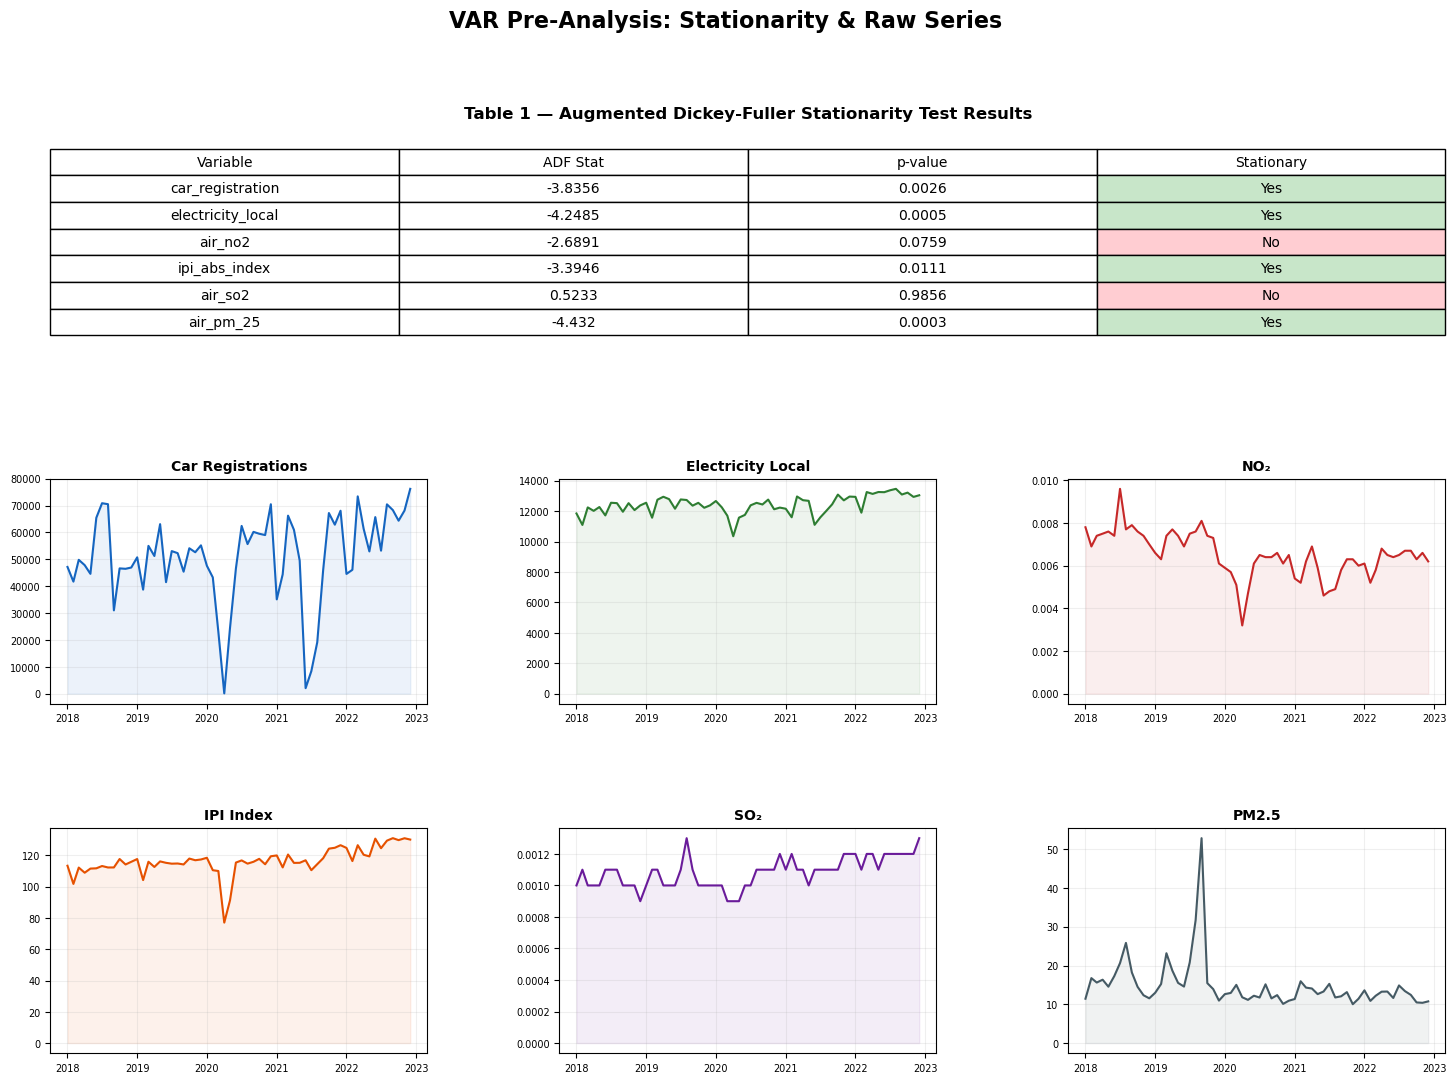

Saved: VarOnlyFileResults/fig1_stationarity.png


In [11]:
BLUE   = '#1565C0'
GREEN  = '#2E7D32'
RED    = '#C62828'
ORANGE = '#E65100'
PURPLE = '#6A1B9A'
GREY   = '#455A64'

fig = plt.figure(figsize=(18, 12))
fig.suptitle('VAR Pre-Analysis: Stationarity & Raw Series',
             fontsize=16, fontweight='bold', y=0.98)
gs = gridspec.GridSpec(3, 3, figure=fig, hspace=0.55, wspace=0.35)

# ── ADF table ────────────────────────────────────────────────────────────────
ax_t = fig.add_subplot(gs[0, :])
ax_t.axis('off')
table_data  = [['Variable', 'ADF Stat', 'p-value', 'Stationary']] +               [[r['Variable'], str(r['ADF Stat']), str(r['p-value']), r['Stationary']]
               for _, r in adf_df.iterrows()]
cell_colors = [['#CFD8DC'] * 4] +               [['#FFFFFF', '#FFFFFF', '#FFFFFF',
                '#C8E6C9' if r['Stationary'] == 'Yes' else '#FFCDD2']
               for _, r in adf_df.iterrows()]
tbl = ax_t.table(cellText=table_data[1:], colLabels=table_data[0],
                  cellLoc='center', loc='center', cellColours=cell_colors[1:])
tbl.auto_set_font_size(False)
tbl.set_fontsize(10)
tbl.scale(1, 1.6)
ax_t.set_title('Table 1 — Augmented Dickey-Fuller Stationarity Test Results',
               fontsize=12, fontweight='bold', pad=8)

# ── Raw series panels ────────────────────────────────────────────────────────
series_info = [
    ('car_registration',  'Car Registrations',  BLUE),
    ('electricity_local', 'Electricity Local',  GREEN),
    ('air_no2',           'NO₂',                RED),
    ('ipi_abs_index',     'IPI Index',           ORANGE),
    ('air_so2',           'SO₂',                PURPLE),
    ('air_pm_25',         'PM2.5',              GREY),
]
for i, (col, label, c) in enumerate(series_info):
    row, col_idx = divmod(i, 3)
    ax = fig.add_subplot(gs[row + 1, col_idx])
    ax.plot(df.index, df[col], color=c, linewidth=1.5)
    ax.fill_between(df.index, df[col], alpha=0.08, color=c)
    ax.set_title(label, fontsize=10, fontweight='bold')
    ax.tick_params(labelsize=7)
    ax.grid(alpha=0.2)

plt.savefig('VarOnlyFileResults/fig1_stationarity.png', dpi=130, bbox_inches='tight')
plt.show()
print("Saved: VarOnlyFileResults/fig1_stationarity.png")
    

## 9. Figure 2 — VAR Model 1: Car Reg + Electricity → NO₂

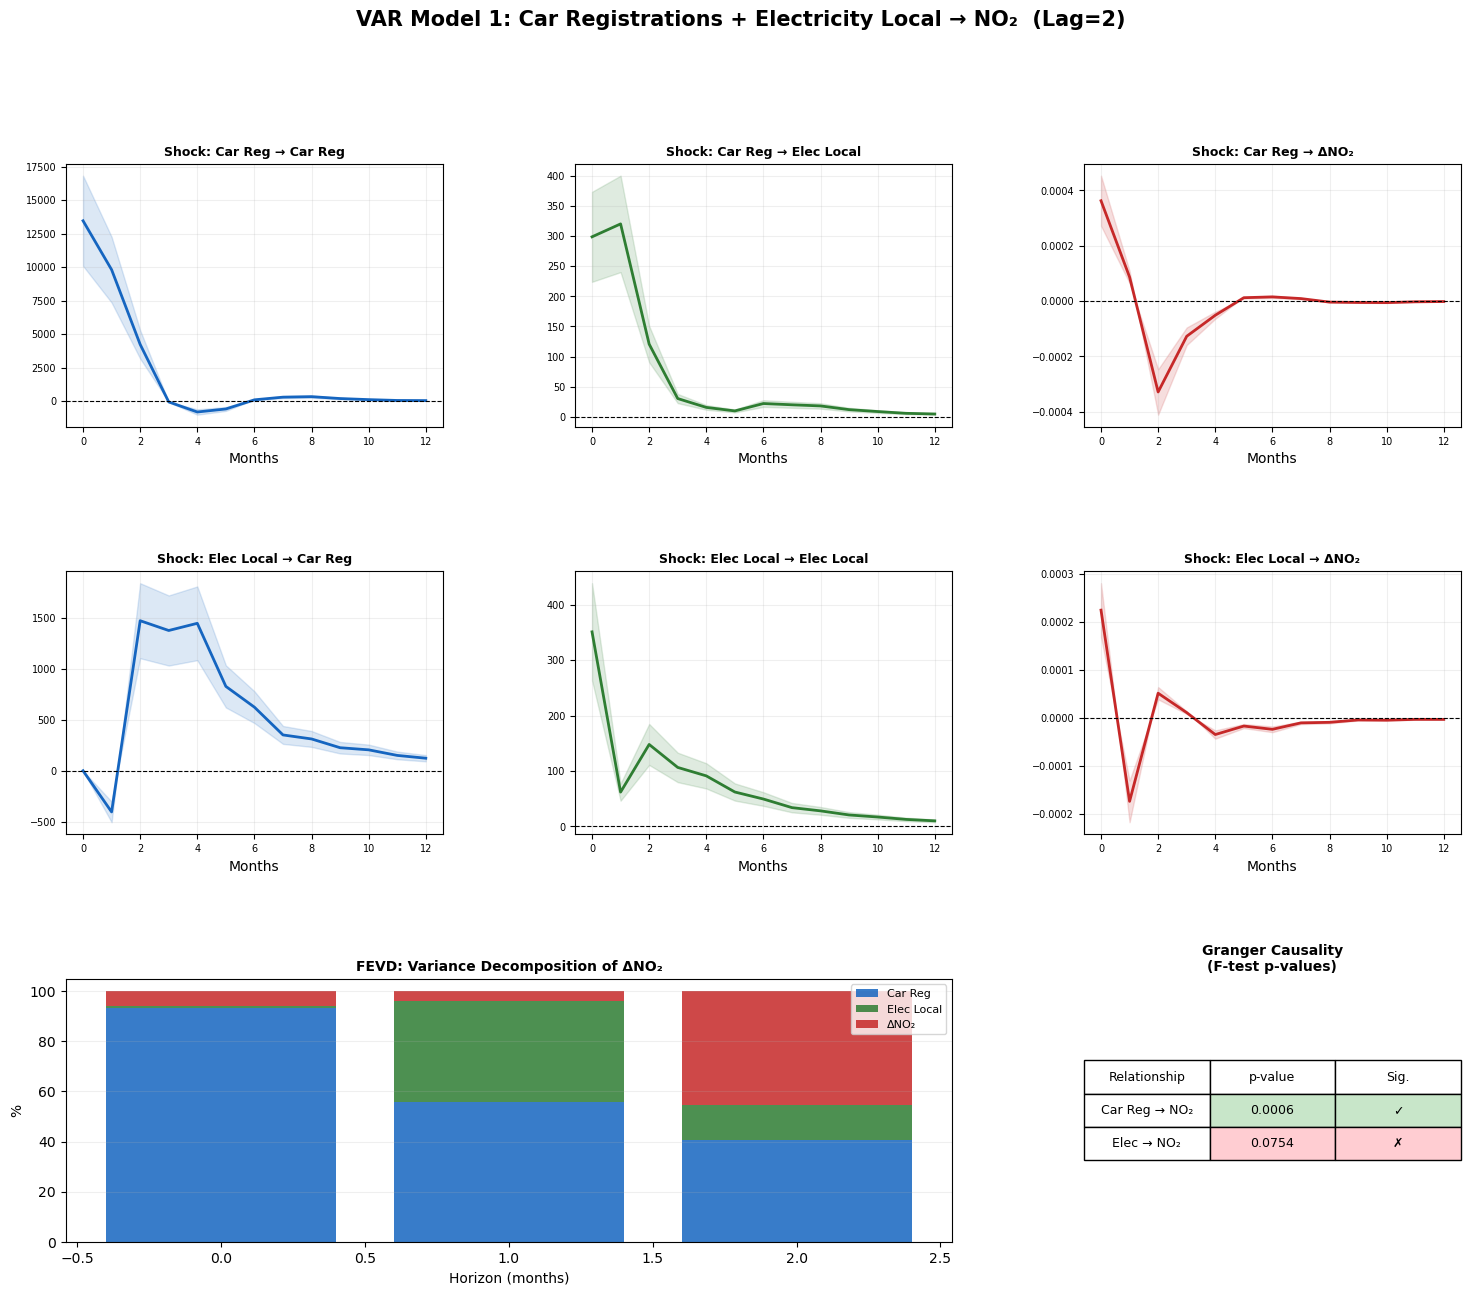

Saved: VarOnlyFileResults/fig2_var1_no2.png


In [12]:
fig2 = plt.figure(figsize=(18, 14))
fig2.suptitle(f'VAR Model 1: Car Registrations + Electricity Local → NO₂  (Lag={lag1})',
               fontsize=15, fontweight='bold', y=0.99)
gs2 = gridspec.GridSpec(3, 3, figure=fig2, hspace=0.55, wspace=0.35)

labels1   = ['Car Reg', 'Elec Local', 'ΔNO₂']
irf1_clrs = [BLUE, GREEN, RED]
n1        = len(v1.columns)

# Row 0: IRF — shock to Car Registration
for j in range(n1):
    ax = fig2.add_subplot(gs2[0, j])
    vals = irf1.orth_irfs[:, j, 0]
    ax.plot(range(len(vals)), vals, color=irf1_clrs[j], linewidth=2)
    ax.fill_between(range(len(vals)), vals * 0.75, vals * 1.25,
                    alpha=0.15, color=irf1_clrs[j])
    ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
    ax.set_title(f'Shock: Car Reg → {labels1[j]}', fontsize=9, fontweight='bold')
    ax.set_xlabel('Months'); ax.grid(alpha=0.2); ax.tick_params(labelsize=7)

# Row 1: IRF — shock to Electricity Local
for j in range(n1):
    ax = fig2.add_subplot(gs2[1, j])
    vals = irf1.orth_irfs[:, j, 1]
    ax.plot(range(len(vals)), vals, color=irf1_clrs[j], linewidth=2)
    ax.fill_between(range(len(vals)), vals * 0.75, vals * 1.25,
                    alpha=0.15, color=irf1_clrs[j])
    ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
    ax.set_title(f'Shock: Elec Local → {labels1[j]}', fontsize=9, fontweight='bold')
    ax.set_xlabel('Months'); ax.grid(alpha=0.2); ax.tick_params(labelsize=7)

# Row 2 left: FEVD for NO₂
ax_fevd1 = fig2.add_subplot(gs2[2, :2])
bottom   = np.zeros(fevd1.decomp.shape[0])
for src in range(n1):
    vals = fevd1.decomp[:, 2, src]   # index 2 = NO₂ response
    ax_fevd1.bar(range(len(vals)), vals * 100, bottom=bottom * 100,
                 label=labels1[src], color=irf1_clrs[src], alpha=0.85)
    bottom += vals
ax_fevd1.set_title('FEVD: Variance Decomposition of ΔNO₂', fontsize=10, fontweight='bold')
ax_fevd1.set_xlabel('Horizon (months)'); ax_fevd1.set_ylabel('%')
ax_fevd1.legend(fontsize=8); ax_fevd1.grid(axis='y', alpha=0.2)

# Row 2 right: Granger causality table
ax_gc1 = fig2.add_subplot(gs2[2, 2])
ax_gc1.axis('off')
gc_pairs1 = [('Car Reg → NO₂', gc_results['car_reg → NO2']),
             ('Elec → NO₂',    gc_results['elec_local → NO2'])]
gc_data1  = [['Relationship', 'p-value', 'Sig.']] +             [[p, f'{v:.4f}', '✓' if v < 0.05 else '✗'] for p, v in gc_pairs1]
gc_clr1   = [['#CFD8DC'] * 3] +             [['#FFFFFF',
              '#C8E6C9' if v < 0.05 else '#FFCDD2',
              '#C8E6C9' if v < 0.05 else '#FFCDD2'] for p, v in gc_pairs1]
t1 = ax_gc1.table(cellText=gc_data1[1:], colLabels=gc_data1[0],
                   cellLoc='center', loc='center', cellColours=gc_clr1[1:])
t1.auto_set_font_size(False); t1.set_fontsize(9); t1.scale(1, 2.0)
ax_gc1.set_title('Granger Causality\n(F-test p-values)', fontsize=10,
                  fontweight='bold', pad=6)

plt.savefig('VarOnlyFileResults/fig2_var1_no2.png', dpi=130, bbox_inches='tight')
plt.show()
print("Saved: VarOnlyFileResults/fig2_var1_no2.png")


## 10. Figure 3 — VAR Model 2: IPI + Electricity → SO₂

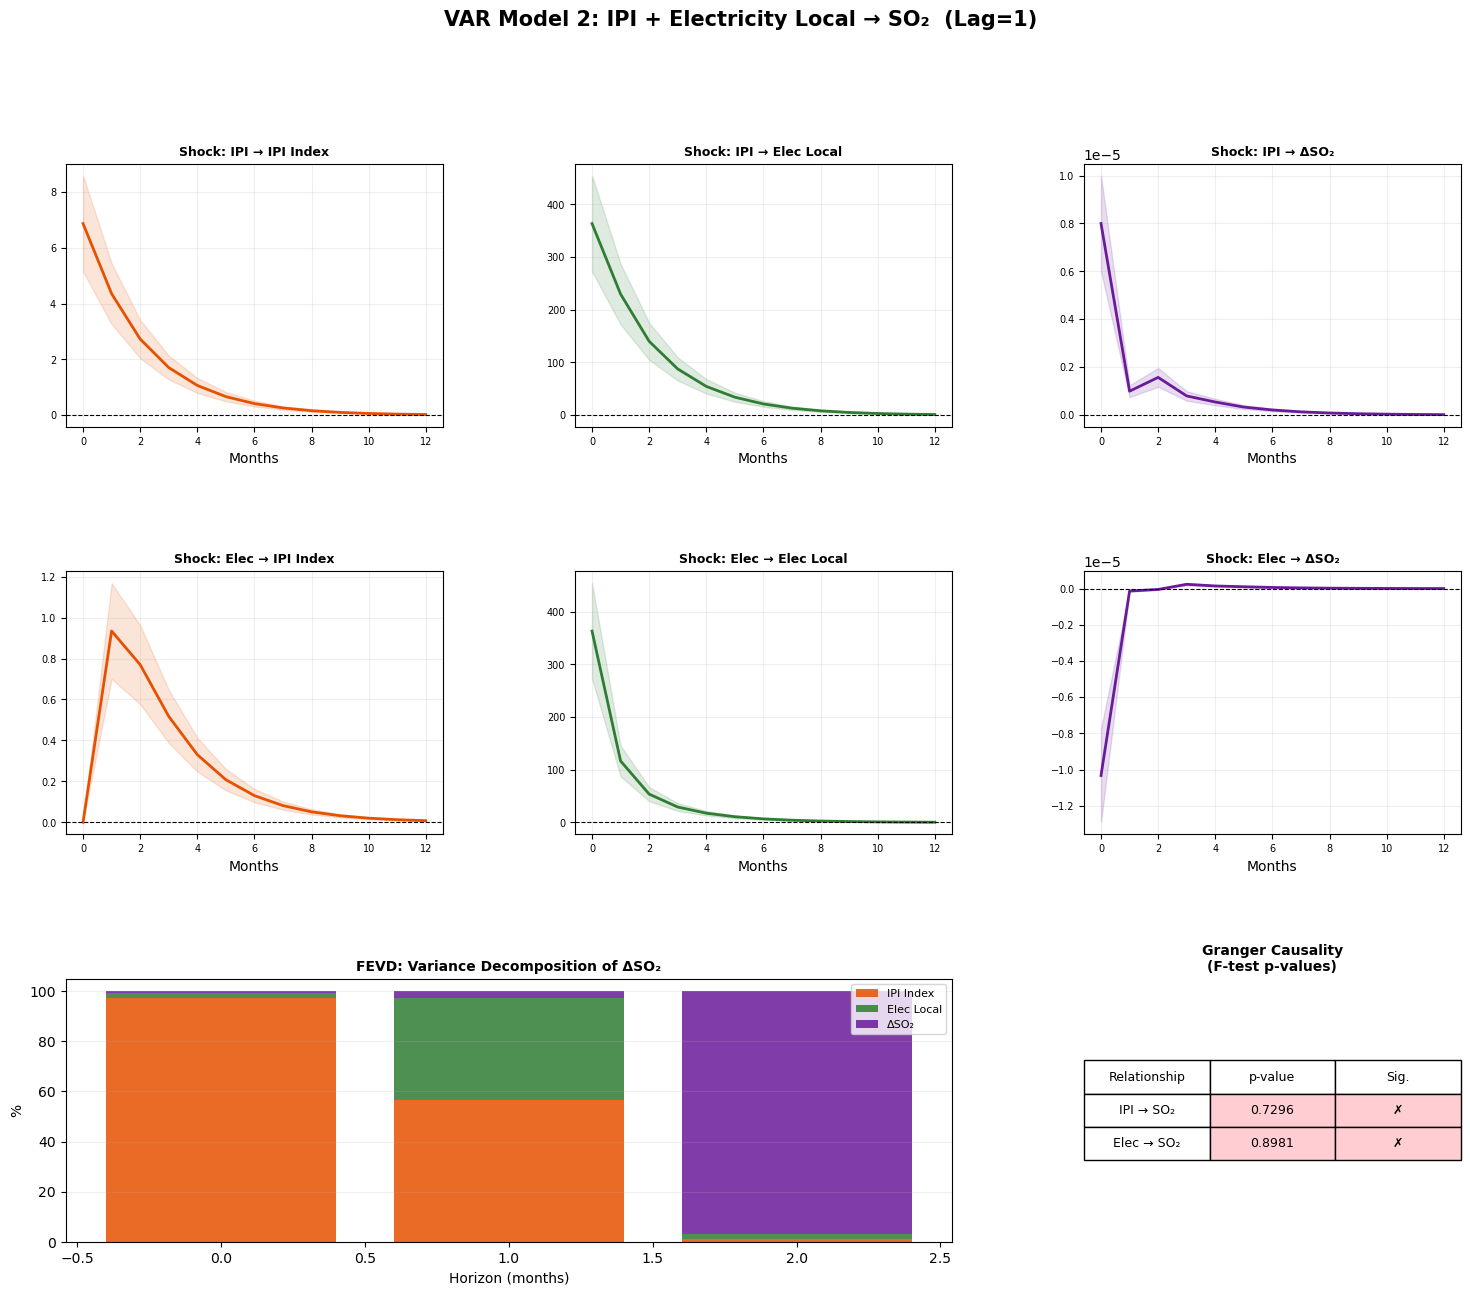

Saved: VarOnlyFileResults/fig3_var2_so2.png


In [13]:
fig3 = plt.figure(figsize=(18, 14))
fig3.suptitle(f'VAR Model 2: IPI + Electricity Local → SO₂  (Lag={lag2})',
               fontsize=15, fontweight='bold', y=0.99)
gs3 = gridspec.GridSpec(3, 3, figure=fig3, hspace=0.55, wspace=0.35)

labels2   = ['IPI Index', 'Elec Local', 'ΔSO₂']
irf2_clrs = [ORANGE, GREEN, PURPLE]
n2        = len(v2.columns)

# Row 0: IRF — shock to IPI
for j in range(n2):
    ax = fig3.add_subplot(gs3[0, j])
    vals = irf2.orth_irfs[:, j, 0]
    ax.plot(range(len(vals)), vals, color=irf2_clrs[j], linewidth=2)
    ax.fill_between(range(len(vals)), vals * 0.75, vals * 1.25,
                    alpha=0.15, color=irf2_clrs[j])
    ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
    ax.set_title(f'Shock: IPI → {labels2[j]}', fontsize=9, fontweight='bold')
    ax.set_xlabel('Months'); ax.grid(alpha=0.2); ax.tick_params(labelsize=7)

# Row 1: IRF — shock to Electricity
for j in range(n2):
    ax = fig3.add_subplot(gs3[1, j])
    vals = irf2.orth_irfs[:, j, 1]
    ax.plot(range(len(vals)), vals, color=irf2_clrs[j], linewidth=2)
    ax.fill_between(range(len(vals)), vals * 0.75, vals * 1.25,
                    alpha=0.15, color=irf2_clrs[j])
    ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
    ax.set_title(f'Shock: Elec → {labels2[j]}', fontsize=9, fontweight='bold')
    ax.set_xlabel('Months'); ax.grid(alpha=0.2); ax.tick_params(labelsize=7)

# Row 2: FEVD + Granger table
ax_fevd2 = fig3.add_subplot(gs3[2, :2])
bottom   = np.zeros(fevd2.decomp.shape[0])
for src in range(n2):
    vals = fevd2.decomp[:, 2, src]
    ax_fevd2.bar(range(len(vals)), vals * 100, bottom=bottom * 100,
                 label=labels2[src], color=irf2_clrs[src], alpha=0.85)
    bottom += vals
ax_fevd2.set_title('FEVD: Variance Decomposition of ΔSO₂', fontsize=10, fontweight='bold')
ax_fevd2.set_xlabel('Horizon (months)'); ax_fevd2.set_ylabel('%')
ax_fevd2.legend(fontsize=8); ax_fevd2.grid(axis='y', alpha=0.2)

ax_gc2 = fig3.add_subplot(gs3[2, 2])
ax_gc2.axis('off')
gc_pairs2 = [('IPI → SO₂',  gc_results['IPI → SO2']),
             ('Elec → SO₂', gc_results['elec_local → SO2'])]
gc_data2  = [['Relationship', 'p-value', 'Sig.']] +             [[p, f'{v:.4f}', '✓' if v < 0.05 else '✗'] for p, v in gc_pairs2]
gc_clr2   = [['#CFD8DC'] * 3] +             [['#FFFFFF',
              '#C8E6C9' if v < 0.05 else '#FFCDD2',
              '#C8E6C9' if v < 0.05 else '#FFCDD2'] for p, v in gc_pairs2]
t2 = ax_gc2.table(cellText=gc_data2[1:], colLabels=gc_data2[0],
                   cellLoc='center', loc='center', cellColours=gc_clr2[1:])
t2.auto_set_font_size(False); t2.set_fontsize(9); t2.scale(1, 2.0)
ax_gc2.set_title('Granger Causality\n(F-test p-values)', fontsize=10,
                  fontweight='bold', pad=6)

plt.savefig('VarOnlyFileResults/fig3_var2_so2.png', dpi=130, bbox_inches='tight')
plt.show()
print("Saved: VarOnlyFileResults/fig3_var2_so2.png")


## 11. Figure 4 — VAR Model 3 (Optional): NO₂ → PM2.5

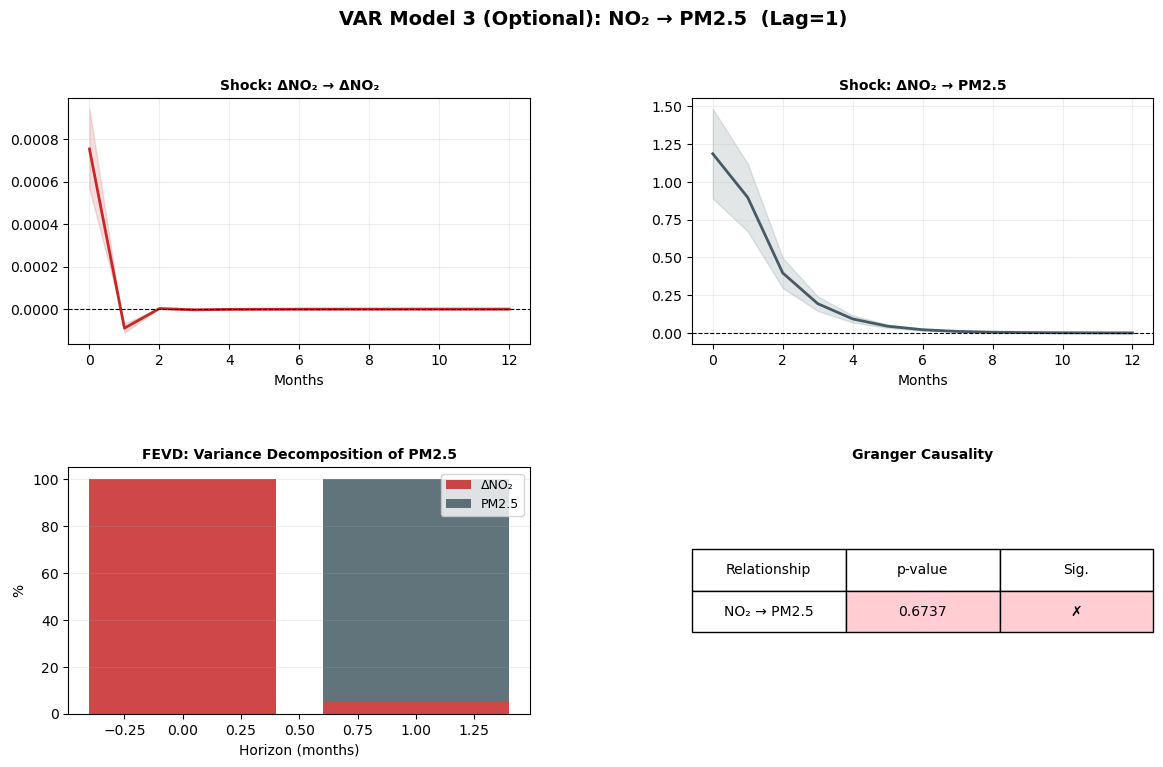

Saved: VarOnlyFileResults/fig4_var3_pm25.png


In [14]:
fig4 = plt.figure(figsize=(14, 8))
fig4.suptitle(f'VAR Model 3 (Optional): NO₂ → PM2.5  (Lag={lag3})',
               fontsize=14, fontweight='bold', y=0.99)
gs4 = gridspec.GridSpec(2, 2, figure=fig4, hspace=0.5, wspace=0.35)

labels3   = ['ΔNO₂', 'PM2.5']
irf3_clrs = [RED, GREY]

# IRF — shock to NO₂
for j in range(2):
    ax = fig4.add_subplot(gs4[0, j])
    vals = irf3.orth_irfs[:, j, 0]
    ax.plot(range(len(vals)), vals, color=irf3_clrs[j], linewidth=2)
    ax.fill_between(range(len(vals)), vals * 0.75, vals * 1.25,
                    alpha=0.15, color=irf3_clrs[j])
    ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
    ax.set_title(f'Shock: ΔNO₂ → {labels3[j]}', fontsize=10, fontweight='bold')
    ax.set_xlabel('Months'); ax.grid(alpha=0.2)

# FEVD for PM2.5
ax_fevd3 = fig4.add_subplot(gs4[1, 0])
bottom   = np.zeros(fevd3.decomp.shape[0])
for src in range(2):
    vals = fevd3.decomp[:, 1, src]
    ax_fevd3.bar(range(len(vals)), vals * 100, bottom=bottom * 100,
                 label=labels3[src], color=irf3_clrs[src], alpha=0.85)
    bottom += vals
ax_fevd3.set_title('FEVD: Variance Decomposition of PM2.5', fontsize=10, fontweight='bold')
ax_fevd3.set_xlabel('Horizon (months)'); ax_fevd3.set_ylabel('%')
ax_fevd3.legend(fontsize=9); ax_fevd3.grid(axis='y', alpha=0.2)

# Granger table
ax_gc3 = fig4.add_subplot(gs4[1, 1])
ax_gc3.axis('off')
p3v       = gc_results['NO2 → PM2.5']
gc_data3  = [['Relationship', 'p-value', 'Sig.'],
             ['NO₂ → PM2.5', f'{p3v:.4f}', '✓' if p3v < 0.05 else '✗']]
gc_clr3   = [['#CFD8DC'] * 3,
             ['#FFFFFF',
              '#C8E6C9' if p3v < 0.05 else '#FFCDD2',
              '#C8E6C9' if p3v < 0.05 else '#FFCDD2']]
t3 = ax_gc3.table(cellText=gc_data3[1:], colLabels=gc_data3[0],
                   cellLoc='center', loc='center', cellColours=gc_clr3[1:])
t3.auto_set_font_size(False); t3.set_fontsize(10); t3.scale(1, 2.5)
ax_gc3.set_title('Granger Causality', fontsize=10, fontweight='bold', pad=6)

plt.savefig('VarOnlyFileResults/fig4_var3_pm25.png', dpi=130, bbox_inches='tight')
plt.show()
print("Saved: VarOnlyFileResults/fig4_var3_pm25.png")


## 12. Figure 5 — Model Diagnostics: Durbin-Watson

Durbin-Watson (DW) statistic tests for serial autocorrelation in residuals.
- DW ≈ 2.0 → no autocorrelation (ideal)
- DW < 1.5 → positive autocorrelation (problematic)
- DW > 2.5 → negative autocorrelation (problematic)


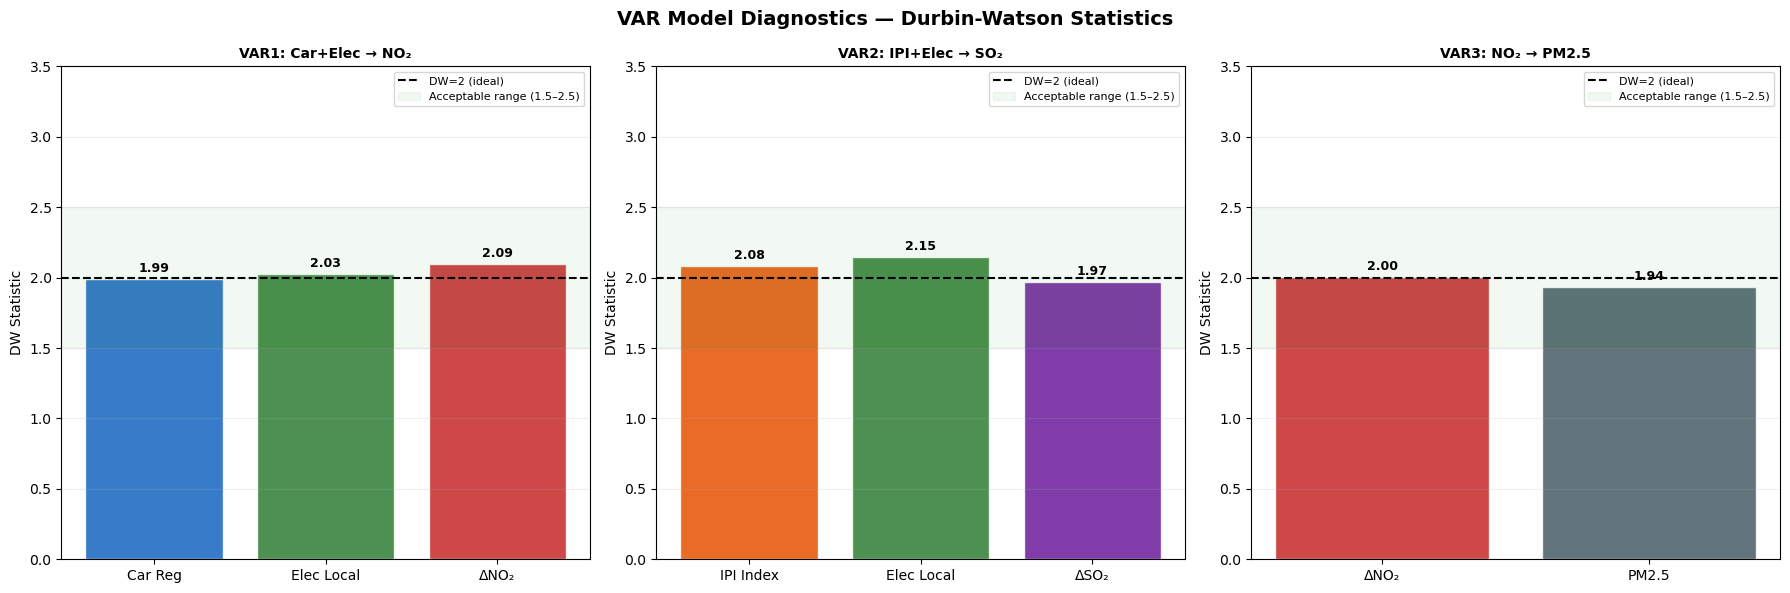

Saved: VarOnlyFileResults/fig5_diagnostics.png


In [15]:
fig5, axes5 = plt.subplots(1, 3, figsize=(18, 6))
fig5.suptitle('VAR Model Diagnostics — Durbin-Watson Statistics',
               fontsize=14, fontweight='bold')

dw_configs = [
    (fit1, 'VAR1: Car+Elec → NO₂',  labels1,  [BLUE, GREEN, RED]),
    (fit2, 'VAR2: IPI+Elec → SO₂',  labels2,  [ORANGE, GREEN, PURPLE]),
    (fit3, 'VAR3: NO₂ → PM2.5',     labels3,  [RED, GREY]),
]

for ax5, (fit, title, lbls, clrs) in zip(axes5, dw_configs):
    resids  = fit.resid
    dw_vals = [durbin_watson(resids.iloc[:, i]) for i in range(resids.shape[1])]
    bars    = ax5.bar(lbls[:len(dw_vals)], dw_vals, color=clrs[:len(dw_vals)],
                      edgecolor='white', alpha=0.85)
    ax5.axhline(2.0, color='black', linewidth=1.5, linestyle='--', label='DW=2 (ideal)')
    ax5.axhspan(1.5, 2.5, alpha=0.05, color='green', label='Acceptable range (1.5–2.5)')
    for b, val in zip(bars, dw_vals):
        ax5.text(b.get_x() + b.get_width() / 2, val + 0.05,
                 f'{val:.2f}', ha='center', fontsize=9, fontweight='bold')
    ax5.set_ylim(0, 3.5)
    ax5.set_title(title, fontsize=10, fontweight='bold')
    ax5.set_ylabel('DW Statistic')
    ax5.legend(fontsize=8)
    ax5.grid(axis='y', alpha=0.2)

plt.tight_layout()
plt.savefig('VarOnlyFileResults/fig5_diagnostics.png', dpi=130, bbox_inches='tight')
plt.show()
print("Saved: VarOnlyFileResults/fig5_diagnostics.png")


## 13. Results Summary

In [16]:
print("=" * 65)
print("  VAR MULTIVARIATE ANALYSIS — SUMMARY OF RESULTS")
print("=" * 65)
print()
print("Dataset: 2018-01 to 2022-12  |  60 monthly observations")
print()
print("─── Stationarity ─────────────────────────────────────────────")
for _, row in adf_df.iterrows():
    note = '(used as-is)' if row['Stationary'] == 'Yes' else '(first-differenced)'
    print(f"  {row['Variable']:<30} {row['Stationary']:<5} {note}")
print()
print("─── Optimal Lags (AIC) ───────────────────────────────────────")
print(f"  VAR1 (Car Reg + Elec → NO₂)  : lag = {lag1}")
print(f"  VAR2 (IPI + Elec → SO₂)      : lag = {lag2}")
print(f"  VAR3 (NO₂ → PM2.5)           : lag = {lag3}")
print()
print("─── Granger Causality ────────────────────────────────────────")
for k, v in gc_results.items():
    sig = '✓ SIGNIFICANT (p<0.05)' if v < 0.05 else '✗ not significant'
    print(f"  {k:<30} p={v:.4f}  {sig}")
print()
print("─── Key Findings ─────────────────────────────────────────────")
print("  • Car registrations significantly Granger-cause NO₂ (p=0.0006)")
print("  • IPI and electricity do NOT significantly Granger-cause SO₂")
print("    → SO₂ likely driven by haze/biomass burning, not industry")
print("  • NO₂ does NOT significantly Granger-cause PM2.5 at monthly freq")
print("    → PM2.5 seasonality (haze) dominates the NO₂ channel")
print("=" * 65)


  VAR MULTIVARIATE ANALYSIS — SUMMARY OF RESULTS

Dataset: 2018-01 to 2022-12  |  60 monthly observations

─── Stationarity ─────────────────────────────────────────────
  car_registration               Yes   (used as-is)
  electricity_local              Yes   (used as-is)
  air_no2                        No    (first-differenced)
  ipi_abs_index                  Yes   (used as-is)
  air_so2                        No    (first-differenced)
  air_pm_25                      Yes   (used as-is)

─── Optimal Lags (AIC) ───────────────────────────────────────
  VAR1 (Car Reg + Elec → NO₂)  : lag = 2
  VAR2 (IPI + Elec → SO₂)      : lag = 1
  VAR3 (NO₂ → PM2.5)           : lag = 1

─── Granger Causality ────────────────────────────────────────
  car_reg → NO2                  p=0.0006  ✓ SIGNIFICANT (p<0.05)
  elec_local → NO2               p=0.0754  ✗ not significant
  IPI → SO2                      p=0.7296  ✗ not significant
  elec_local → SO2               p=0.8981  ✗ not significant
  NO